In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./dataset.csv')

df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [3]:
df = df.drop_duplicates(subset='ID')
df = df.drop(columns=['ID', 'No_Pation'])
df['CLASS'] = df['CLASS'].str.strip()
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
y = df['CLASS']
X = df.drop(columns='CLASS')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, stratify=y)

In [6]:
from sklearn.ensemble import RandomForestClassifier

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [8]:
gender_col = ['Gender']
class_col = ['CLASS']
num_cols = X.select_dtypes(include='number').columns
transformer = ColumnTransformer(
    transformers=[
        ('gender', OneHotEncoder(handle_unknown='ignore', sparse_output=False), gender_col),
    ('num', StandardScaler(), num_cols)],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', transformer),
    ('model', RandomForestClassifier(class_weight='balanced'))
])

In [9]:
from sklearn.model_selection import cross_val_score, GridSearchCV

In [10]:
param_grid = {
    'model__n_estimators': [100,150,200,250,300,350,400],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1,2,4]
}

model = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted'
)


In [11]:
model.fit(X_train, y_train)
y_preds = model.predict(X_test)

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

0.98
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 250}
              precision    recall  f1-score   support

           N       0.93      1.00      0.96        25
           P       1.00      0.85      0.92        13
           Y       0.99      0.99      0.99       162

    accuracy                           0.98       200
   macro avg       0.97      0.94      0.96       200
weighted avg       0.98      0.98      0.98       200



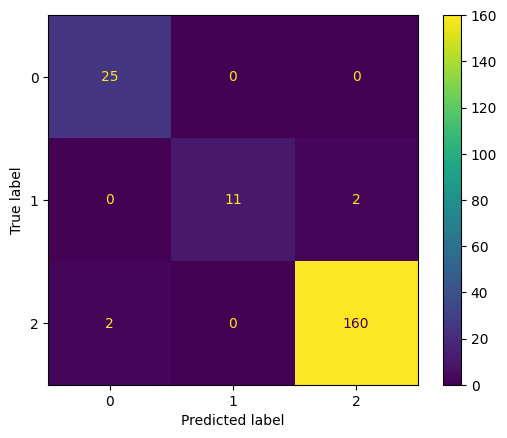

In [13]:
m = confusion_matrix(y_test, y_preds)
print(accuracy_score(y_test, y_preds))
disp = ConfusionMatrixDisplay(m)
print(model.best_params_)
print(classification_report(y_test, y_preds))
disp.plot()